# Q5: Linear vs Polynomial Regression (Numerical + Visual)

This notebook generates synthetic nonlinear data and compares:
- Linear regression (degree 1)
- Polynomial regression (degree 5)

It reports training MSE and saves figures for the lecture notes.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Reproducibility
rng = np.random.default_rng(42)

# Output directory for figures (relative to notebook location)
img_dir = Path('img') / 'lecture8'
img_dir.mkdir(parents=True, exist_ok=True)

In [2]:
# Synthetic data
N = 50
x = rng.uniform(0, 1, size=N)
sigma = 0.1
eps = rng.normal(0, sigma, size=N)
y = np.sin(2*np.pi*x) + eps

# Design matrices
X_lin = np.column_stack([np.ones_like(x), x])
deg = 5
X_poly = np.vander(x, N=deg+1, increasing=True)


In [3]:
# Fit via least squares
theta_lin, *_ = np.linalg.lstsq(X_lin, y, rcond=None)
theta_poly, *_ = np.linalg.lstsq(X_poly, y, rcond=None)

# Predictions
yhat_lin = X_lin @ theta_lin
yhat_poly = X_poly @ theta_poly

# Training MSE
mse_lin = float(np.mean((y - yhat_lin)**2))
mse_poly = float(np.mean((y - yhat_poly)**2))

print(f'Training MSE (linear, deg 1): {mse_lin:.4f}')
print(f'Training MSE (poly, deg {deg}): {mse_poly:.4f}')


Training MSE (linear, deg 1): 0.1691
Training MSE (poly, deg 5): 0.0052


In [4]:
# Dense grid for plotting
xx = np.linspace(0, 1, 400)
yy_true = np.sin(2*np.pi*xx)
XX_lin = np.column_stack([np.ones_like(xx), xx])
XX_poly = np.vander(xx, N=deg+1, increasing=True)
yy_lin = XX_lin @ theta_lin
yy_poly = XX_poly @ theta_poly


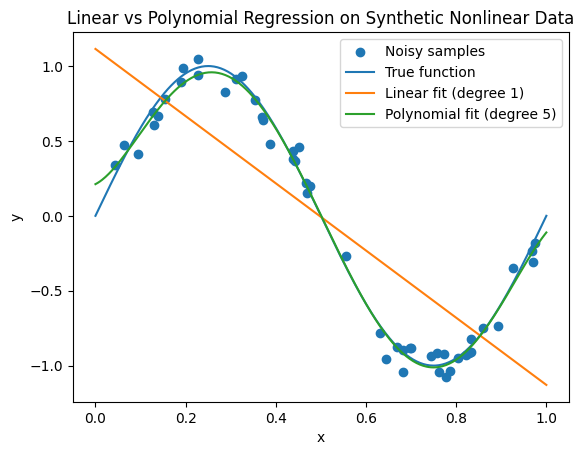

Saved: img/lecture8/qa_q5_linear_vs_poly_fit.png


In [5]:
# Figure 1: data + fits
plt.figure()
plt.scatter(x, y, label='Noisy samples')
plt.plot(xx, yy_true, label='True function')
plt.plot(xx, yy_lin, label='Linear fit (degree 1)')
plt.plot(xx, yy_poly, label=f'Polynomial fit (degree {deg})')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Linear vs Polynomial Regression on Synthetic Nonlinear Data')
plt.legend()
fig1_path = img_dir / 'qa_q5_linear_vs_poly_fit.png'
plt.savefig(fig1_path, bbox_inches='tight', dpi=200)
plt.show()
print('Saved:', fig1_path)


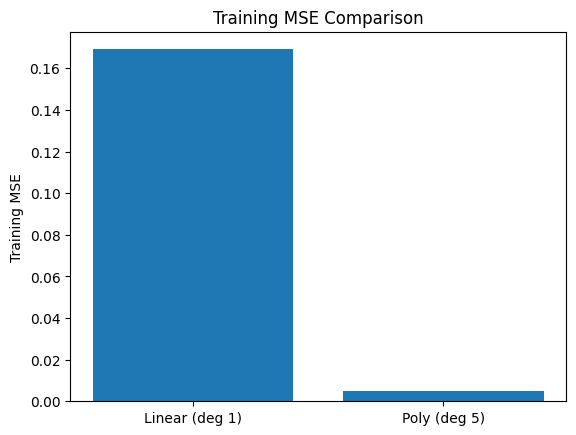

Saved: img/lecture8/qa_q5_mse_comparison.png


In [6]:
# Figure 2: MSE comparison
plt.figure()
plt.bar(['Linear (deg 1)', f'Poly (deg {deg})'], [mse_lin, mse_poly])
plt.ylabel('Training MSE')
plt.title('Training MSE Comparison')
fig2_path = img_dir / 'qa_q5_mse_comparison.png'
plt.savefig(fig2_path, bbox_inches='tight', dpi=200)
plt.show()
print('Saved:', fig2_path)
